In [16]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt



=============================================================================
### TASK 1 – Importing and Preprocessing FINO1 Measurement Data
=============================================================================
 
Goal
----
Load the 1 Hz raw measurement data from the FINO1 offshore platform (file
1301.txt), replace the missing-data sentinel value -999 with IEEE NaN, and
report how many such sentinels were found.
 
Data file columns
-----------------
  Time   – ISO-formatted timestamp string  (YYYY-MM-DD HH:MM:SS)
  d90    – Wind-vane direction at  90 m  [°]
  d33    – Wind-vane direction at  33 m  [°]
  u100   – Cup-anemometer wind speed at 100 m  [m/s]
  u90    –                              at  90 m  [m/s]
  u80    –                              at  80 m  [m/s]
  u70    –                              at  70 m  [m/s]
  u60    –                              at  60 m  [m/s]
  u50    –                              at  50 m  [m/s]
  u40    –                              at  40 m  [m/s]
  u33    –                              at  33 m  [m/s]
 
Algorithm overview
------------------
  1. Read the tab-separated ASCII file with pandas.read_csv().
  2. Parse the Time column into proper datetime objects.
  3. In every numeric column, replace the value -999 with np.nan.
  4. Count and report the total number of replacements.
  5. Display a sanity-check summary of the resulting DataFrame.
  6. Save the cleaned data to a compressed pickle file for reuse in later
     tasks (this is the Python equivalent of MATLAB's .mat binary format).
 
=============================================================================

In [17]:
file_path = os.path.join('data', '1301.txt')
df = pd.read_csv(
    file_path,
    sep       = "\t",          # columns are separated by tabs
    # na_values = ["-999",       # integer sentinel  → NaN
    #              "-999.0",     # float sentinel    → NaN
    #              "-999.00"],   # alternative float → NaN
    parse_dates     = ["Time"],    # convert the Time column to datetime64
    engine    = "c",           # use the fast C parser (default, but explicit)
)
# Remove any whitespace in column names (safety measure)
df.columns = df.columns.str.strip()
print(f"File loaded successfully.")
print(f"  • Rows read : {len(df):>10,}")
print(f"  • Columns   : {list(df.columns)}")
df.head(5)

File loaded successfully.
  • Rows read :  2,163,923
  • Columns   : ['Time', 'd90', 'd33', 'u100', 'u90', 'u80', 'u70', 'u60', 'u50', 'u40', 'u33']


,Time,d90,d33,u100,u90,u80,u70,u60,u50,u40,u33
0,2013-01-01 00:00:00,228,228,16.25,15.49,14.85,14.53,14.43,13.45,12.75,12.55
1,2013-01-01 00:00:01,225,227,15.95,15.49,15.10,14.58,14.28,13.70,13.00,12.20
2,2013-01-01 00:00:02,228,227,15.65,15.84,14.85,14.68,14.53,13.75,12.45,12.55
3,2013-01-01 00:00:03,225,227,16.35,15.99,14.85,14.73,14.43,13.80,12.85,13.20
4,2013-01-01 00:00:04,225,225,16.25,16.04,15.59,15.13,14.18,13.15,13.70,13.20


In [18]:
# ── Numeric columns only (exclude Time) ──────────────────────────────────────
numeric_cols = [c for c in df.columns if c != "Time"]
 
nan_per_column = (df[numeric_cols] == -999).sum()  # Series: NaN count per col
# total_nan      = int(nan_per_column.sum())          # grand total across all cols
 
# ── Datetime column ───────────────────────────────────────────────────────────
missing_timestamps = int(df["Time"].isnull().sum())
 
print("─" * 68)
print("NaN (= replaced -999) counts per numeric column:")
print("─" * 68)
for col, count in nan_per_column.items():
    print(f"  {col:<8}: {count:>6,}")
print("─" * 68)
# print(f"  {'TOTAL':<8}: {total_nan:>6,}  replacements in numeric columns")
print(f"  {'Time NaT':<8}: {missing_timestamps:>6,}  missing/unparseable timestamps")
print("─" * 68)
 
# if total_nan == 0:
#     print("\n→ No -999 sentinels were found in this dataset.")
#     print("  The exercise note states: 'It is not guaranteed that any")
#     print("  occurrence is present in the provided data.'")
#     print("  This is consistent with the data for month 2013-01.")
# else:
#     print(f"\n→ {total_nan:,} -999 sentinel(s) found and replaced with NaN.")
# print()
nan_per_column

────────────────────────────────────────────────────────────────────
NaN (= replaced -999) counts per numeric column:
────────────────────────────────────────────────────────────────────
  d90     :      0
  d33     :      0
  u100    :      0
  u90     :      0
  u80     :      0
  u70     :      0
  u60     :      0
  u50     :      0
  u40     :      0
  u33     :      0
────────────────────────────────────────────────────────────────────
  Time NaT:      0  missing/unparseable timestamps
────────────────────────────────────────────────────────────────────


d90     0
d33     0
u100    0
u90     0
u80     0
u70     0
u60     0
u50     0
u40     0
u33     0
dtype: int64

In [19]:
print("─" * 68)
print("DataFrame info  (types, non-null counts):")
print("─" * 68)
df.info(memory_usage="deep")
print()
 
print("─" * 68)
print("Basic statistics for numeric columns:")
print("─" * 68)
print(df[numeric_cols].describe().round(3).to_string())
print()
 
# ── Time-axis check ───────────────────────────────────────────────────────────
print("─" * 68)
print("Time-axis info:")
print("─" * 68)
t_start = df["Time"].min()
t_end   = df["Time"].max()
n_rows  = len(df)
print(f"  First timestamp : {t_start}")
print(f"  Last  timestamp : {t_end}")
print(f"  Total rows      : {n_rows:,}")
print(f"  Expected rows   : {int((t_end - t_start).total_seconds()) + 1:,}"
      f"  (if perfectly continuous at 1 Hz)")
print()

────────────────────────────────────────────────────────────────────
DataFrame info  (types, non-null counts):
────────────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2163923 entries, 0 to 2163922
Data columns (total 11 columns):
 #   Column  Dtype         
---  ------  -----         
 0   Time    datetime64[ns]
 1   d90     int64         
 2   d33     int64         
 3   u100    float64       
 4   u90     float64       
 5   u80     float64       
 6   u70     float64       
 7   u60     float64       
 8   u50     float64       
 9   u40     float64       
 10  u33     float64       
dtypes: datetime64[ns](1), float64(8), int64(2)
memory usage: 181.6 MB

────────────────────────────────────────────────────────────────────
Basic statistics for numeric columns:
────────────────────────────────────────────────────────────────────
               d90          d33         u100          u90          u80          u70          u6

In [20]:
# The file can be reloaded in later tasks with:
#   df = pd.read_pickle("fino_raw.pkl")
 
df.to_pickle('data/fino_raw.pkl')
pkl_size_mb = os.path.getsize('data/fino_raw.pkl') / 1e6
print("─" * 68)
print(f"  File size: {pkl_size_mb:.1f} MB")
print("─" * 68)
print()
print("Task 1 complete.")

────────────────────────────────────────────────────────────────────
  File size: 190.4 MB
────────────────────────────────────────────────────────────────────

Task 1 complete.


### Task 2: Generating Continuous Time Axis.

In [21]:
# Load Task 1 output
df = pd.read_pickle("./data/fino_raw.pkl").replace(-999, np.nan)
df.head()

,Time,d90,d33,u100,u90,u80,u70,u60,u50,u40,u33
0,2013-01-01 00:00:00,228,228,16.25,15.49,14.85,14.53,14.43,13.45,12.75,12.55
1,2013-01-01 00:00:01,225,227,15.95,15.49,15.10,14.58,14.28,13.70,13.00,12.20
2,2013-01-01 00:00:02,228,227,15.65,15.84,14.85,14.68,14.53,13.75,12.45,12.55
3,2013-01-01 00:00:03,225,227,16.35,15.99,14.85,14.73,14.43,13.80,12.85,13.20
4,2013-01-01 00:00:04,225,225,16.25,16.04,15.59,15.13,14.18,13.15,13.70,13.20


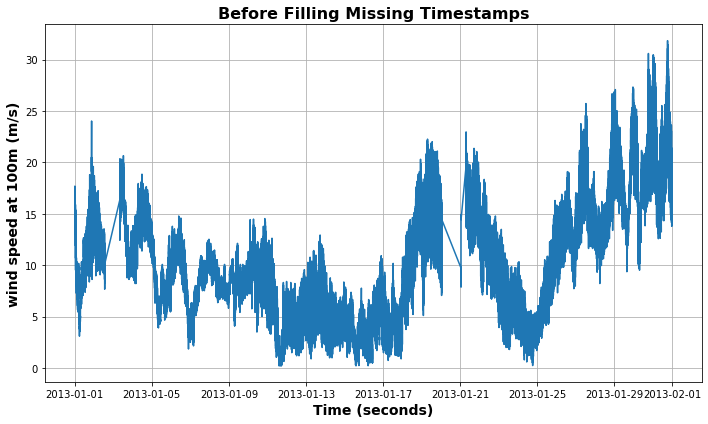

In [22]:
# visualize gap distribution before filling in the missing timestamps
df_real = df.copy()
df_real = df_real.set_index("Time")
plt.figure(figsize=(10, 6))
plt.plot(df_real.index, df_real["u100"])
plt.xlabel('Time (seconds)', fontsize=14, fontweight='bold')
plt.ylabel('wind speed at 100m (m/s)', fontsize=14, fontweight='bold')
plt.title('Before Filling Missing Timestamps', fontsize=16, fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:

# Ensure datetime format
df["Time"] = pd.to_datetime(df["Time"])

# Sort by time
df = df.sort_values("Time").reset_index(drop=True)

# Count duplicate of each time stamp
duplicate_count = df["Time"].duplicated().sum()

#Keep only the first occurrence of each time stamp
df = df.drop_duplicates(subset="Time", keep="first").copy()

# Building a continous 1-second time axis
start_time = df["Time"].min()
end_time = df["Time"].max()
full_time = pd.date_range(start=start_time, end=end_time, freq="1s")
# Reindex the DataFrame to the full time axis
df_continuous= (
    df
    .set_index("Time")
    .reindex(full_time)
    .rename_axis("Time")
    .reset_index()
)

# Count inserted missing rows
n_missing_seconds = len(full_time) - len(df)

time_diff = df["Time"].diff().dt.total_seconds()
gap_lengths = (time_diff - 1).dropna()
gap_lengths = gap_lengths[gap_lengths > 0]
print("=" * 68)
print("Start time:", start_time)
print("End time:", end_time)
print()
print("=" * 68)
print("Original rows:", len(df))
print()
print("=" * 68)
print("Duplicate timestamps:", duplicate_count)
print()
print("=" * 68)
print("Unique timestamps:", len(df))
print()
print("=" * 68)
print("Continuous 1 Hz rows:", len(df_continuous))
print()
print("=" * 68)
print("Missing seconds inserted:", n_missing_seconds)
print()
print("=" * 68)
print("Number of gaps:", len(gap_lengths))
print()
print("=" * 68)
print("Largest gap [s]:", int(gap_lengths.max()))
print("-" * 68)


Start time: 2013-01-01 00:00:00
End time: 2013-01-31 23:49:13

Original rows: 2163868

Duplicate timestamps: 55

Unique timestamps: 2163868

Continuous 1 Hz rows: 2677754

Missing seconds inserted: 513886

Number of gaps: 53178

Largest gap [s]: 86216
--------------------------------------------------------------------


In [24]:
# # missing counts per day in continuous index
# missing_per_day = df_continuous['u100'].isna().groupby(df_continuous.index.date).sum()
# missing_per_day[:5], missing_per_day.max()


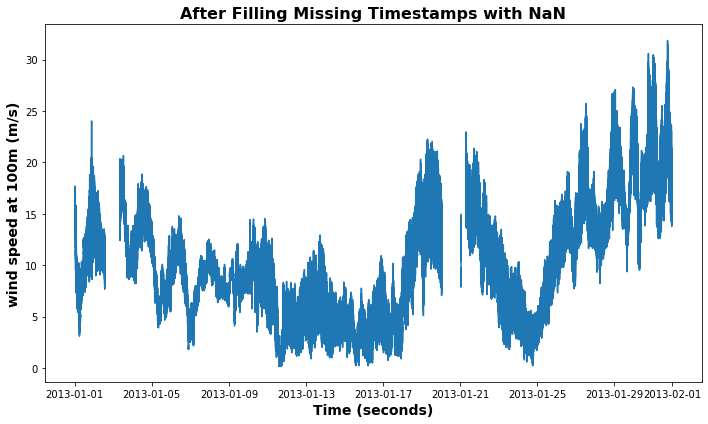

In [25]:
# visualize gap distribution After filling in the missing timestamps and fiiling in the missing values with NaN
df_copy = df_continuous.set_index("Time").copy()
plt.figure(figsize=(10,6))
plt.plot(df_copy.index, df_copy["u100"])
plt.xlabel('Time (seconds)', fontsize=14, fontweight='bold')
plt.ylabel('wind speed at 100m (m/s)', fontsize=14, fontweight='bold')
plt.title('After Filling Missing Timestamps with NaN', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 3: Averaging to 10 min Mean Values

Since the wind vane and cup anemometer measurements are treated as separate instruments, we therefore we use the unweighted average methods to compute the direction mean, using unit vectors only:

#### Wind Direction Vector Averaging Formulas

##### For $d_{33}$:
Convert individual measurements to radians:
$$\phi_{33,i} = d_{33,i} \frac{\pi}{180}$$

Decompose into horizontal ($u$) and vertical ($v$) components:
$$u_{33,i} = \sin(\phi_{33,i}), \qquad v_{33,i} = \cos(\phi_{33,i})$$

Calculate the average components over a 10-minute interval ($n$ samples):
$$\bar{u}_{33} = \frac{1}{n} \sum_{i=1}^n u_{33,i}, \qquad \bar{v}_{33} = \frac{1}{n} \sum_{i=1}^n v_{33,i}$$

Calculate the average angle in radians using the four-quadrant inverse tangent:
$$\bar{\phi}_{33} = \operatorname{atan2}(\bar{u}_{33}, \bar{v}_{33})$$

Convert the average result back to degrees:
$$\bar{d}_{33} = \bar{\phi}_{33} \frac{180}{\pi}$$

---

##### For $d_{90}$:
Convert individual measurements to radians:
$$\phi_{90,i} = d_{90,i} \frac{\pi}{180}$$

Decompose into horizontal ($u$) and vertical ($v$) components:
$$u_{90,i} = \sin(\phi_{90,i}), \qquad v_{90,i} = \cos(\phi_{90,i})$$

Calculate the average components over a 10-minute interval ($n$ samples):
$$\bar{u}_{90} = \frac{1}{n} \sum_{i=1}^n u_{90,i}, \qquad \bar{v}_{90} = \frac{1}{n} \sum_{i=1}^n v_{90,i}$$

Calculate the average angle in radians:
$$\bar{\phi}_{90} = \operatorname{atan2}(\bar{u}_{90}, \bar{v}_{90})$$

Convert the average result back to degrees:
$$\bar{d}_{90} = \bar{\phi}_{90} \frac{180}{\pi}$$

In [26]:
df_continuous = df_continuous.set_index("Time").sort_index()

In [27]:
# Computing the mean angles of wind direction
angle_df = pd.DataFrame(index=df_continuous.index)
angle_df["u_x_33"] = np.sin(np.deg2rad(df_continuous["d33"]))
angle_df["u_y_33"] = np.cos(np.deg2rad(df_continuous["d33"]))
angle_df["u_x_90"] = np.sin(np.deg2rad(df_continuous["d90"]))
angle_df["u_y_90"] = np.cos(np.deg2rad(df_continuous["d90"]))
angle_df = angle_df.resample("10min").mean()

In [28]:
# Taking the arctan of the mean sine and cosine to get the mean angle
angle_df["mean_d33"] = np.rad2deg(np.arctan2(angle_df["u_x_33"], angle_df["u_y_33"])) % 360
angle_df["mean_d90"] = np.rad2deg(np.arctan2(angle_df["u_x_90"], angle_df["u_y_90"])) % 360

# Masking out angle measurements having less than 50% of valid data in the 10min window:
# directions
count_d33 = df_continuous["d33"].resample("10min").count()
count_d90 = df_continuous["d90"].resample("10min").count()

valid_threshold = 0.5 * 10 * 60  # 50% of 10 minutes at 1 Hz

angle_df["mean_d33"] = angle_df["mean_d33"].where(count_d33 >= valid_threshold, np.nan)
angle_df["mean_d90"] = angle_df["mean_d90"].where(count_d90 >= valid_threshold, np.nan)

In [29]:
# resampling wind speed to 10min
wind_speeds = df_continuous.drop(columns=["d33", "d90"])
wind_speed_10min = wind_speeds.resample("10min").mean()
wind_speed_std = wind_speeds.resample("10min").std()  
speed_count = wind_speeds.resample("10min").count()

wind_speed_10min = wind_speed_10min.mask(speed_count < valid_threshold)
wind_speed_std = wind_speed_std.mask(speed_count < valid_threshold)

wind_speed_10min.head()

,u100,u90,u80,u70,u60,u50,u40,u33
Time,,,,,,,,
2013-01-01 00:00:00,15.496122,15.350414,14.922222,14.445359,13.974946,13.566231,12.853725,12.487930
2013-01-01 00:10:00,15.289835,15.103510,14.637441,14.134717,13.693272,13.264168,12.470969,12.098026
2013-01-01 00:20:00,14.481085,14.383830,13.970745,13.549894,13.069787,12.650851,11.897021,11.445872
2013-01-01 00:30:00,14.773929,14.593634,14.043887,13.556450,13.082164,12.679076,11.932080,11.510021
2013-01-01 00:40:00,14.917583,14.755410,14.268293,13.790421,13.282084,12.770288,12.071907,11.600532


In [30]:

mean_10_min_values = pd.concat([
    wind_speed_10min.add_suffix("_mean"),
    wind_speed_std.add_suffix("_std"),
    angle_df["mean_d33"].rename("d33_mean"),
    angle_df["mean_d90"].rename("d90_mean")
], axis=1)

mean_10_min_values.head()

,u100_mean,u90_mean,u80_mean,u70_mean,u60_mean,u50_mean,u40_mean,u33_mean,u100_std,u90_std,u80_std,u70_std,u60_std,u50_std,u40_std,u33_std,d33_mean,d90_mean
Time,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,15.496122,15.350414,14.922222,14.445359,13.974946,13.566231,12.853725,12.487930,0.665413,0.660954,0.597372,0.586191,0.617570,0.610576,0.681536,0.748382,229.402719,227.919262
2013-01-01 00:10:00,15.289835,15.103510,14.637441,14.134717,13.693272,13.264168,12.470969,12.098026,0.845385,0.831323,0.804129,0.739900,0.708829,0.724130,0.697745,0.683722,228.239499,227.968987
2013-01-01 00:20:00,14.481085,14.383830,13.970745,13.549894,13.069787,12.650851,11.897021,11.445872,0.420870,0.435968,0.505891,0.512516,0.509330,0.520580,0.625538,0.636433,225.829650,225.619162
2013-01-01 00:30:00,14.773929,14.593634,14.043887,13.556450,13.082164,12.679076,11.932080,11.510021,0.509608,0.487028,0.490836,0.513077,0.495613,0.511166,0.564826,0.629785,225.901285,224.638702
2013-01-01 00:40:00,14.917583,14.755410,14.268293,13.790421,13.282084,12.770288,12.071907,11.600532,0.397705,0.378888,0.441232,0.475450,0.496546,0.521336,0.495850,0.549378,224.727619,224.166334


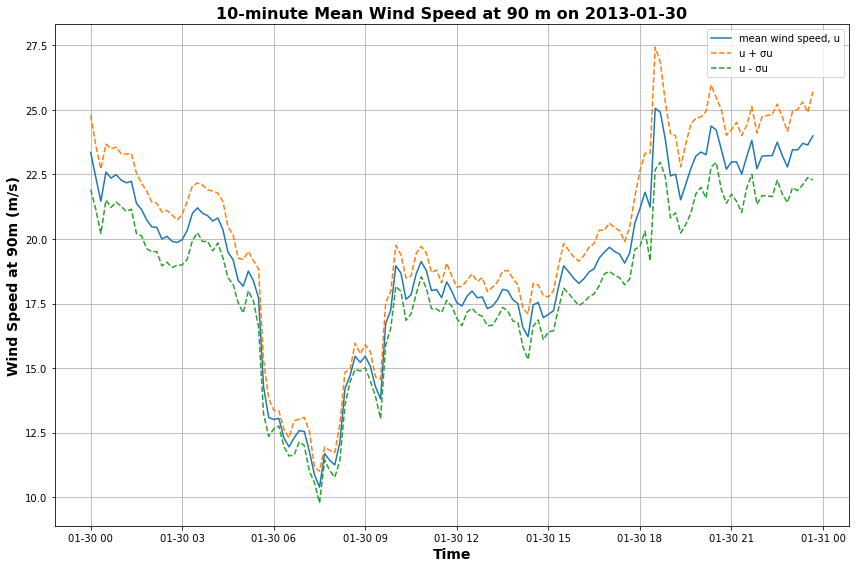

In [33]:
# Plot the ten minute means of u90 for the day 2013-01-30

plt.figure(figsize=(12, 8))
plt.plot(
    mean_10_min_values.loc["2013-01-30"].index,
    mean_10_min_values.loc["2013-01-30"]["u90_mean"],
    label="mean wind speed, u"
)
plt.plot(
    mean_10_min_values.loc["2013-01-30"].index,
    mean_10_min_values.loc["2013-01-30"]["u90_mean"] + mean_10_min_values.loc["2013-01-30"]["u90_std"], 
    label="u + σu", linestyle="--"
)
plt.plot(
    mean_10_min_values.loc["2013-01-30"].index,
    mean_10_min_values.loc["2013-01-30"]["u90_mean"] - mean_10_min_values.loc["2013-01-30"]["u90_std"], 
    label="u - σu", linestyle="--"
)
plt.xlabel("Time", fontsize=14, fontweight="bold")
plt.ylabel("Wind Speed at 90m (m/s)", fontsize=14, fontweight="bold")
plt.title("10-minute Mean Wind Speed at 90 m on 2013-01-30", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

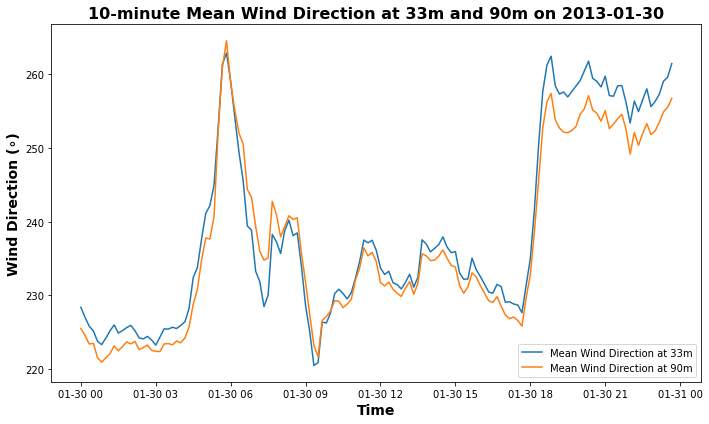

In [32]:
# Visualizing Wind Direction on 2013-01-30 at 33m and 90m
plt.figure(figsize=(10, 6))
plt.plot(
    mean_10_min_values.loc["2013-01-30"].index,
    mean_10_min_values.loc["2013-01-30"]["d33_mean"],
    label="Mean Wind Direction at 33m"
)
plt.plot(
    mean_10_min_values.loc["2013-01-30"].index,
    mean_10_min_values.loc["2013-01-30"]["d90_mean"],
    label="Mean Wind Direction at 90m"
)
plt.xlabel("Time", fontsize=14, fontweight="bold")
plt.ylabel("Wind Direction (∘)", fontsize=14, fontweight="bold")
plt.title("10-minute Mean Wind Direction at 33m and 90m on 2013-01-30", fontsize=16, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

### Task 4: Extreme values - Outlier Detection using $5\sigma$ Threshold

**Objective:** Identify and visualize signal spikes in the 1 Hz wind speed data using statistical binning.

**Methodology**:

1.  **Data Source:** Work with the raw **1 Hz $u_{100}$ data** on the continuous time axis generated in Task 2.
2.  **Temporal Binning:** Divide the month into non-overlapping **10-minute bins** ($j$).
3.  **Statistical Calculation:** For each 10-minute bin, compute:
    * The mean wind speed: $\mu_j$
    * The standard deviation: $\sigma_j$
4.  **Comparison Logic:** Compare every 1 Hz value ($u_i$) within a specific bin against that bin's statistics.
5.  **Flagging Criteria:** Flag any data point that satisfies the following condition:
    $$|u_i - \mu_j| > 5\sigma_j$$

**Requirements**:

* **Identification:** Find at least one 10-minute interval that contains at least one flagged point.
* **Visualization:** Plot the full 10-minute interval, highlighting the outliers.
* **Interpretation:** Provide a meteorological or technical interpretation of the flagged points (e.g., sensor noise vs. extreme physical gusts).

In [17]:
# Extracting the wind speed at 100m from the actual data
u100 = df_continuous.copy()["u100"]
print(u100.index[:5])
u100.head()

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 00:00:01',
               '2013-01-01 00:00:02', '2013-01-01 00:00:03',
               '2013-01-01 00:00:04'],
              dtype='datetime64[ns]', name='Time', freq=None)


Time
2013-01-01 00:00:00    16.25
2013-01-01 00:00:01    15.95
2013-01-01 00:00:02    15.65
2013-01-01 00:00:03    16.35
2013-01-01 00:00:04    16.25
Name: u100, dtype: float64

In [18]:
# create a dataframe centered on the raw 1 Hz u100 signal
u100_check = pd.DataFrame({"u100": u100})

# attach the 10-minute mean to every 1 Hz sample
u100_check["mean_10min"] = u100.resample("10min").transform("mean")

# attach the 10-minute standard deviation to every 1 Hz sample
u100_check["std_10min"] = u100.resample("10min").transform("std")


# compute absolute deviation from the local 10-minute mean
u100_check["abs_dev"] = (u100_check["u100"] - u100_check["mean_10min"]).abs()

# compute the local 5-sigma threshold
u100_check["threshold_5sigma"] = 5 * u100_check["std_10min"]

# inspect the result
u100_check.head(15)

,u100,mean_10min,std_10min,abs_dev,threshold_5sigma
Time,,,,,
2013-01-01 00:00:00,16.25,15.496122,0.665413,0.753878,3.327067
2013-01-01 00:00:01,15.95,15.496122,0.665413,0.453878,3.327067
2013-01-01 00:00:02,15.65,15.496122,0.665413,0.153878,3.327067
2013-01-01 00:00:03,16.35,15.496122,0.665413,0.853878,3.327067
2013-01-01 00:00:04,16.25,15.496122,0.665413,0.753878,3.327067
2013-01-01 00:00:05,16.25,15.496122,0.665413,0.753878,3.327067
2013-01-01 00:00:06,16.70,15.496122,0.665413,1.203878,3.327067
2013-01-01 00:00:07,17.10,15.496122,0.665413,1.603878,3.327067
2013-01-01 00:00:08,16.35,15.496122,0.665413,0.853878,3.327067


In [19]:
# flag points that exceed the 5-sigma criterion
u100_check["is_spike_5sigma"] = (
    (u100_check["abs_dev"] > u100_check["threshold_5sigma"])
)

# inspect only the flagged spike candidates
spike_points = u100_check[u100_check["is_spike_5sigma"]]
print("Number of flagged spike points:", len(spike_points))

spike_points.head(10)

Number of flagged spike points: 25


,u100,mean_10min,std_10min,abs_dev,threshold_5sigma,is_spike_5sigma
Time,,,,,,
2013-01-01 16:00:15,10.38,13.633538,0.609814,3.253538,3.049072,True
2013-01-03 22:20:56,10.88,12.531216,0.316749,1.651216,1.583743,True
2013-01-04 00:20:00,11.18,13.121996,0.302957,1.941996,1.514785,True
2013-01-04 01:00:21,10.33,11.672737,0.268155,1.342737,1.340774,True
2013-01-04 01:00:23,9.62,11.672737,0.268155,2.052737,1.340774,True
2013-01-04 01:15:38,10.98,12.095134,0.205979,1.115134,1.029897,True
2013-01-04 02:42:17,11.38,13.228249,0.300964,1.848249,1.504820,True
2013-01-06 09:29:36,14.79,12.296154,0.496897,2.493846,2.484483,True
2013-01-07 12:50:40,9.07,10.237040,0.224838,1.167040,1.124189,True


In [20]:
# keep only the flagged spike points
spike_points = u100_check[u100_check["is_spike_5sigma"]].copy()

# assign each flagged point to the start time of its 10-minute interval
spike_points["interval_start"] = spike_points.index.floor("10min")

# count how many flagged points occur in each 10-minute interval
spike_intervals = spike_points.groupby("interval_start").size().rename("number_of_spikes")

# convert to dataframe for easier inspection
spike_intervals = spike_intervals.to_frame()

# sort so intervals with the most flagged points appear first
spike_intervals = spike_intervals.sort_values("number_of_spikes", ascending=False)

# inspect results
print("Number of 10-minute intervals containing at least one 5σ event:", len(spike_intervals))
spike_intervals.head(10)

Number of 10-minute intervals containing at least one 5σ event: 18


,number_of_spikes
interval_start,
2013-01-16 04:50:00,4
2013-01-30 06:00:00,3
2013-01-04 01:00:00,2
2013-01-08 12:30:00,2
2013-01-03 22:20:00,1
2013-01-01 16:00:00,1
2013-01-04 02:40:00,1
2013-01-06 09:20:00,1
2013-01-04 01:10:00,1


In [21]:
# choose one interval from the detected spike intervals
chosen_interval = spike_intervals.index[1]

# define the end of the 10-minute interval
interval_end = chosen_interval + pd.Timedelta(minutes=10)

# extract the raw 1 Hz data in that interval
interval_data = u100_check.loc[chosen_interval:interval_end - pd.Timedelta(seconds=1)].copy()

# get the interval statistics from the first row
mean_u100 = interval_data["mean_10min"].iloc[0]
std_u100 = interval_data["std_10min"].iloc[0]

# compute threshold lines
plus_1sigma = mean_u100 + std_u100
minus_1sigma = mean_u100 - std_u100
plus_5sigma = mean_u100 + 5 * std_u100
minus_5sigma = mean_u100 - 5 * std_u100

# create a local time axis in seconds from 0 to 599
interval_data["t_sec"] = np.arange(len(interval_data))

# inspect
print("Chosen interval start:", chosen_interval)
print("Chosen interval end:", interval_end - pd.Timedelta(seconds=1))
print("Number of rows in interval:", len(interval_data))
print("Mean u100:", mean_u100)
print("Std u100:", std_u100)
print("5σ upper threshold:", plus_5sigma)
print("5σ lower threshold:", minus_5sigma)

interval_data.head()

Chosen interval start: 2013-01-30 06:00:00
Chosen interval end: 2013-01-30 06:09:59
Number of rows in interval: 600
Mean u100: 11.247227191413238
Std u100: 0.34380435939480536
5σ upper threshold: 12.966248988387264
5σ lower threshold: 9.528205394439212


,u100,mean_10min,std_10min,abs_dev,threshold_5sigma,is_spike_5sigma,t_sec
Time,,,,,,,
2013-01-30 06:00:00,10.68,11.247227,0.343804,0.567227,1.719022,False,0
2013-01-30 06:00:01,10.78,11.247227,0.343804,0.467227,1.719022,False,1
2013-01-30 06:00:02,10.88,11.247227,0.343804,0.367227,1.719022,False,2
2013-01-30 06:00:03,10.93,11.247227,0.343804,0.317227,1.719022,False,3
2013-01-30 06:00:04,10.68,11.247227,0.343804,0.567227,1.719022,False,4


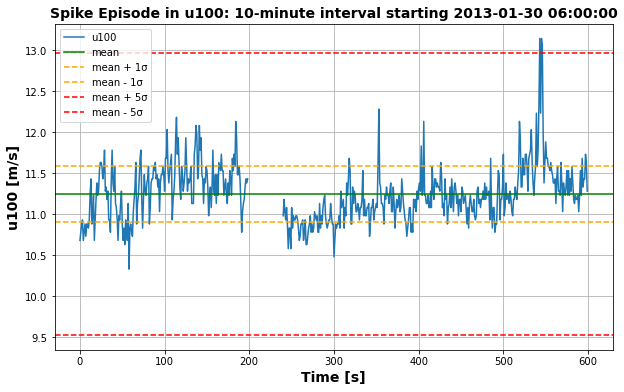

In [55]:
plt.figure(figsize=(10, 6))

# raw u100 signal
plt.plot(interval_data["t_sec"], interval_data["u100"], label="u100")

# mean line
plt.axhline(mean_u100, linestyle="-", label="mean", color="green")

# ±1 sigma lines
plt.axhline(plus_1sigma, linestyle="--", label="mean + 1σ", color="orange")
plt.axhline(minus_1sigma, linestyle="--", label="mean - 1σ", color="orange")

# ±5 sigma lines
plt.axhline(plus_5sigma, linestyle="--", label="mean + 5σ", color="red")
plt.axhline(minus_5sigma, linestyle="--", label="mean - 5σ", color="red")

plt.xlabel("Time [s]", fontsize=14, fontweight="bold")
plt.ylabel("u100 [m/s]", fontsize=14, fontweight="bold")
plt.title(f"Spike Episode in u100: 10-minute interval starting {chosen_interval}", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
interval_data[interval_data["is_spike_5sigma"]][["u100", "mean_10min", "std_10min", "abs_dev", "threshold_5sigma"]]

,u100,mean_10min,std_10min,abs_dev,threshold_5sigma
Time,,,,,
2013-01-30 06:09:03,13.14,11.247227,0.343804,1.892773,1.719022
2013-01-30 06:09:05,13.14,11.247227,0.343804,1.892773,1.719022
2013-01-30 06:09:06,13.04,11.247227,0.343804,1.792773,1.719022


### Task 5: Analysis of Wind Speed Increments

**Objective:** Analyze the small-scale temporal dynamics of the wind speed signal at 90m and compare its statistics to a Gaussian distribution.

#### Methodology:
1.  **Data Source:** Use the **$u_{90}$ wind-speed signal** on the continuous 1 Hz time axis for the entire month.
2.  **Increment Calculation:** Compute the wind speed increment ($\delta u_\tau$) at every second:
    $$\delta u_\tau = u(t + \tau) - u(t)$$
    using a time lag of:
    $$\tau = 1 \text{ s}$$

#### Statistical Analysis:
* **Collection:** Gather all 1-second differences calculated for the entire month.
* **Normalization:** Normalize the increments by their own standard deviation ($\sigma_{\delta u}$):
    $$\delta u_{norm} = \frac{\delta u_\tau}{\sigma_{\delta u}}$$
* **PDF Computation:** Compute the **Probability Density Function (PDF)** of these normalized increments.
* **Visualization:** Plot the resulting PDF on a **semi-logarithmic axis** (log-scale on the y-axis).
* **Comparison:** Overlay a **Gaussian (Normal) PDF** with a mean of 0 and unit standard deviation ($\sigma = 1$) to identify "heavy tails" or intermittency in the wind data.

In [24]:
# make a working copy
df_task5 = df_continuous.copy()

# extract the 90 m wind speed
u90 = df_task5["u90"]

# quick inspection
print(u90.head())
print("Total samples:", len(u90))
print("Missing values:", u90.isna().sum())

Time
2013-01-01 00:00:00    15.49
2013-01-01 00:00:01    15.49
2013-01-01 00:00:02    15.84
2013-01-01 00:00:03    15.99
2013-01-01 00:00:04    16.04
Name: u90, dtype: float64
Total samples: 2677754
Missing values: 513886


In [25]:
# compute 1-second increments
du_1s = u90.diff()

# inspect
print(du_1s.head(10))
print("Number of increment samples:", len(du_1s))
print("Missing increments:", du_1s.isna().sum())

# removing invalid increments (those involving NaN values)
du_1s = du_1s.dropna()

# Computing the standard deviation of the 1-second increments
std_du_1s = du_1s.std()

# normalize increments by their standard deviation
du_1s_normalized = du_1s / std_du_1s    

# inspect the normalized increments
du_1s_normalized.max()


Time
2013-01-01 00:00:00     NaN
2013-01-01 00:00:01    0.00
2013-01-01 00:00:02    0.35
2013-01-01 00:00:03    0.15
2013-01-01 00:00:04    0.05
2013-01-01 00:00:05    0.41
2013-01-01 00:00:06    0.85
2013-01-01 00:00:07   -0.35
2013-01-01 00:00:08   -1.31
2013-01-01 00:00:09   -0.20
Name: u90, dtype: float64
Number of increment samples: 2677754
Missing increments: 567065


13.85039361342034

In [26]:
for n_bins in [80, 100, 120, 150]:
    pdf_values, bin_edges = np.histogram(du_1s_normalized, bins=n_bins, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    print(n_bins, "bin width =", bin_edges[1] - bin_edges[0])

80 bin width = 0.32740721744972845
100 bin width = 0.26192577395978134
120 bin width = 0.21827147829981897
150 bin width = 0.17461718263985482


In [60]:
# choose number of bins
n_bins = 95

# compute histogram as a probability density
pdf_values, bin_edges = np.histogram(du_1s_normalized, bins=n_bins, density=True)

# compute bin centers for plotting
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# inspect
print("Number of bins:", n_bins)
print()
print("Length of pdf_values:", len(pdf_values))
print()
print("Length of bin_centers:", len(bin_centers))
print()
print("First 10 PDF values:", pdf_values[:10])
print()
print("First 10 bin centers:", bin_centers[:10])

# compute Gaussian reference PDF on the same x-axis
gaussian_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * bin_centers**2)

Number of bins: 95

Length of pdf_values: 95

Length of bin_centers: 95

First 10 PDF values: [1.71838757e-06 0.00000000e+00 1.71838757e-06 3.43677514e-06
 3.43677514e-06 5.15516271e-06 3.43677514e-06 1.20287130e-05
 6.87355028e-06 8.59193785e-06]

First 10 bin centers: [-12.20432811 -11.92861677 -11.65290543 -11.37719409 -11.10148275
 -10.82577141 -10.55006007 -10.27434872  -9.99863738  -9.72292604]


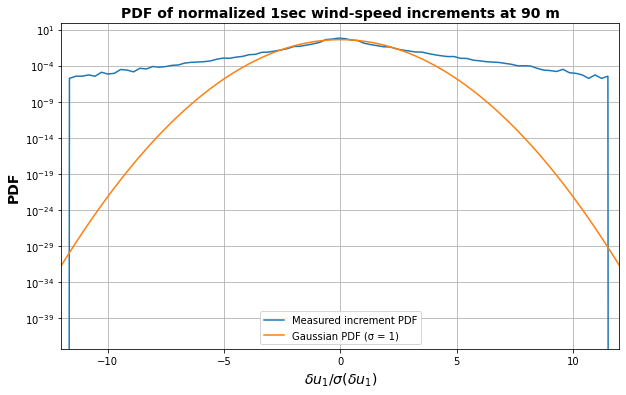

In [61]:
plt.figure(figsize=(10, 6))

# measured increment PDF
plt.semilogy(bin_centers, pdf_values, label="Measured increment PDF")

# Gaussian reference PDF
plt.semilogy(bin_centers, gaussian_pdf, label="Gaussian PDF (σ = 1)")

plt.xlabel(r'$\delta u_1 / \sigma(\delta u_1)$', fontsize=14, fontweight='bold')
plt.ylabel('PDF', fontsize=14, fontweight='bold')
plt.title('PDF of normalized 1sec wind-speed increments at 90 m', fontsize=14, fontweight='bold')
plt.xlim(-12, 12)
plt.grid(True)
plt.tight_layout
plt.legend()

plt.show()

### Task 6: Analyzing Mast-Induced Distortion vs. Vertical Wind Shear

**Objective:** Distinguish between actual vertical wind speed differences (wind shear) and artificial measurement distortions caused by the physical structure of the FINO 1 mast.

**Theoretical Context**:
In an undisturbed environment, the wind speed difference between two vertical levels is defined as:
$$\Delta u = \bar{u}_{100} - \bar{u}_{90}$$

Ideally, $\Delta u$ should be **small and slightly positive**, reflecting the standard increase of wind speed with height (the wind profile). However, physical obstructions on the mast introduce directional biases:
* **Tower Shadow (90m level):** The 90m cup anemometer is mounted on a boom on the **SE side (135°)**. When the wind blows from specific directions, the mast structure stands upwind of the sensor, reducing the measured speed and artificially inflating $\Delta u$.
* **Lightning Protection (100m level):** The top anemometer is enclosed in a lightning protection cage. The vertical rods of this cage create flow distortions at **multiples of 90°**.

**Requirements**:
1.  **Data Source:** Use the **10-minute averages** computed in Task 3.
2.  **Calculation:** Define the velocity difference for each 10-minute interval:
    $$\Delta u = \bar{u}_{100} - \bar{u}_{90}$$
3.  **Directional Variable:** As there is no sensor at 100m, use the 10-minute mean wind direction from the 90m sensor ($\bar{d}_{90}$) as the independent variable.
4.  **Visualization:** Generate a scatter plot where each valid 10-minute interval represents a coordinate:
    $$\text{Point} = (\bar{d}_{90}, \bar{u}_{100} - \bar{u}_{90})$$

**Interpretation Goals**:
* **Identify Tower Shadow:** Locate the range of angles where the mast structure blocks the 90m anemometer (centered around the boom orientation).
* **Identify Cage Distortion:** Observe periodic deviations in $\Delta u$ occurring at 90° intervals caused by the lightning protection rods.
* **Quantify Shear:** Determine the "baseline" $\Delta u$ in sectors where the wind is undisturbed by the mast.

In [29]:
mean_10_min_values.head()

,u100_mean,u90_mean,u80_mean,u70_mean,u60_mean,u50_mean,u40_mean,u33_mean,u100_std,u90_std,u80_std,u70_std,u60_std,u50_std,u40_std,u33_std,d33_mean,d90_mean
Time,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,15.496122,15.350414,14.922222,14.445359,13.974946,13.566231,12.853725,12.487930,0.665413,0.660954,0.597372,0.586191,0.617570,0.610576,0.681536,0.748382,229.402719,227.919262
2013-01-01 00:10:00,15.289835,15.103510,14.637441,14.134717,13.693272,13.264168,12.470969,12.098026,0.845385,0.831323,0.804129,0.739900,0.708829,0.724130,0.697745,0.683722,228.239499,227.968987
2013-01-01 00:20:00,14.481085,14.383830,13.970745,13.549894,13.069787,12.650851,11.897021,11.445872,0.420870,0.435968,0.505891,0.512516,0.509330,0.520580,0.625538,0.636433,225.829650,225.619162
2013-01-01 00:30:00,14.773929,14.593634,14.043887,13.556450,13.082164,12.679076,11.932080,11.510021,0.509608,0.487028,0.490836,0.513077,0.495613,0.511166,0.564826,0.629785,225.901285,224.638702
2013-01-01 00:40:00,14.917583,14.755410,14.268293,13.790421,13.282084,12.770288,12.071907,11.600532,0.397705,0.378888,0.441232,0.475450,0.496546,0.521336,0.495850,0.549378,224.727619,224.166334


In [30]:
task6_df = mean_10_min_values[["u100_mean", "u90_mean", "d90_mean"]].copy().dropna()
task6_df.head()

,u100_mean,u90_mean,d90_mean
Time,,,
2013-01-01 00:00:00,15.496122,15.350414,227.919262
2013-01-01 00:10:00,15.289835,15.103510,227.968987
2013-01-01 00:20:00,14.481085,14.383830,225.619162
2013-01-01 00:30:00,14.773929,14.593634,224.638702
2013-01-01 00:40:00,14.917583,14.755410,224.166334


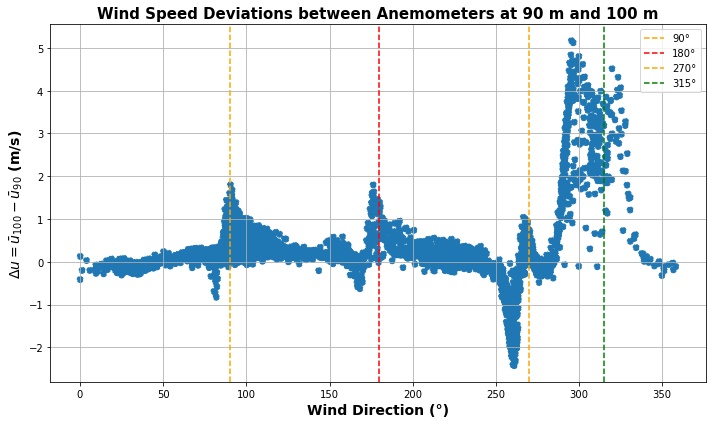

In [63]:
task6_df["delta_u"] = task6_df["u100_mean"] - task6_df["u90_mean"]

plt.figure(figsize=(10,6))
plt.scatter(task6_df["d90_mean"], task6_df["delta_u"], linestyle="--")
plt.axvline(90, linestyle="--", label="90°", color="orange")
plt.axvline(180, linestyle="--", label="180°", color="red")
plt.axvline(270, linestyle="--", label="270°", color="orange")
plt.axvline(315, linestyle="--", label="315°", color="green")
plt.xlabel("Wind Direction (°)", fontsize=14, fontweight="bold")
plt.ylabel(r'$\Delta u = \bar{u}_{100} - \bar{u}_{90}$ (m/s)', fontsize=14, fontweight="bold")
plt.title("Wind Speed Deviations between Anemometers at 90 m and 100 m", fontsize=15, fontweight="bold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()